In [ ]:
from itertools import product
import numpy as np

def FW_transform(x, y):
    n=x.shape[1]
    f_hat = np.zeros(2**n)
    basis_bits_l = [
    [i for i, bit in enumerate(mask) if bit]
    for mask in product([0, 1], repeat=n)
    ]

    for i, S in enumerate(basis_bits_l):
        xi_i = np.prod(x[:, S], axis=1)
        f_hat[i] = np.mean(xi_i*y)
    return f_hat

def degree(f_hat):
    n = int(np.log2(len(f_hat)))
    basis_bits_l = [
    [i for i, bit in enumerate(mask) if bit]
    for mask in product([0, 1], repeat=n)
    ]
    non_zero = f_hat!=0
    if np.sum(non_zero) == 0:
        return 0
    degree = max([len(basis_bits_l[i]) for i in np.where(non_zero)[0]])
    return degree

def data_to_bit_string(data):
    ndims = data.shape[1]
    n_samples = data.shape[0]
    for dim in range(ndims):
        x = data[:,dim]
        
for bit_string in list(product([0, 1], repeat=nbits)):
    x = np.array(bit_string)
    x = x*2 -1
    y = f(int("".join(map(str, bit_string)), 2)/2**nbits)
    x_l.append(x)
    y_l.append(y)
x = np.array(x_l)
y = np.array(y_l)

S = 3
A = 1
nbits_input = S + 2*A + 1
nbits_latent = int(np.ceil(np.log2(S))) + int(np.ceil(np.log2(2*A+1)))
input_strings = np.array(list(product([-1, 1], repeat=nbits_input)))
latent_strings = np.array(list(product([-1, 1], repeat=nbits_latent)))

x_base = np.ones(nbits_input)*(-1)
x_l = []
y_l = []
for s in range(S):
    for a in range(-A, A+1):
        s_curr = s
        s_next = s_curr + a
        if s_next > S-1 or s_next < 0:
            continue
        x_curr = x_base.copy()
        a_i = a - A
        x_curr[s] = 1
        x_curr[S+a_i] = 1
        x_l.append(x_curr)
        y_l.append(s_next)
x = np.array(x_l)
y = np.array(y_l)

f_hat = FW_transform(x, y)
print(f'nbits input: {nbits_input}, nbits latent: {nbits_latent}, degree: {degree(f_hat)}')
print(degree(f_hat)/nbits_input)


basis_bits_l = [
[i for i, bit in enumerate(mask) if bit]
for mask in product([0, 1], repeat=S)
]



nbits input: 6, nbits latent: 4, degree: 6
1.0


In [ ]:
from __future__ import annotations

import math
from typing import Any, Dict, Iterable, List, Tuple

import numpy as np


def data_to_bit_string(x: Iterable[Any]) -> Tuple[np.ndarray, Dict[Any, str]]:
    """
    Convert a 1D array-like x into a 2D binary code matrix using the minimal
    number of bits needed to represent all unique values.

    Steps:
      1) Find unique values in x (preserving first-appearance order)
      2) Assign each unique value an integer id 0..k-1
      3) Use b = ceil(log2(k)) bits (minimal), with a special case k<=1 -> b=1
      4) Return:
           - codes: shape (len(x), b) with 0/1 ints
           - mapping: dict {value: bitstring}

    Example:
      x = ["cat","dog","cat","bird"]
      k=3 -> b=2
      mapping might be {"cat":"00","dog":"01","bird":"10"}
      codes -> [[0,0],[0,1],[0,0],[1,0]]
    """
    x_list = list(x)
    n = len(x_list)

    # Unique values in order of first appearance
    mapping_id: Dict[Any, int] = {}
    uniques: List[Any] = []
    for v in x_list:
        if v not in mapping_id:
            mapping_id[v] = len(uniques)
            uniques.append(v)

    k = len(uniques)
    bits = 1 if k <= 1 else int(math.ceil(math.log2(k)))

    # Integer ids for each x value
    ids = np.fromiter((mapping_id[v] for v in x_list), dtype=np.int64, count=n)

    # Convert ids -> bit matrix (MSB first)
    # Example bits=3: id=5 (101) => [1,0,1]
    shifts = np.arange(bits - 1, -1, -1, dtype=np.int64)
    codes = ((ids[:, None] >> shifts[None, :]) & 1).astype(float)

    return codes

def data_to_binary(data):
    binary_data = []
    for dim in range(data.shape[1]):
        binary_data.append(data_to_bit_string(data[:,dim]))

    return np.concatenate(binary_data, axis=1)


nbits input: 16, degree: 16
1.0


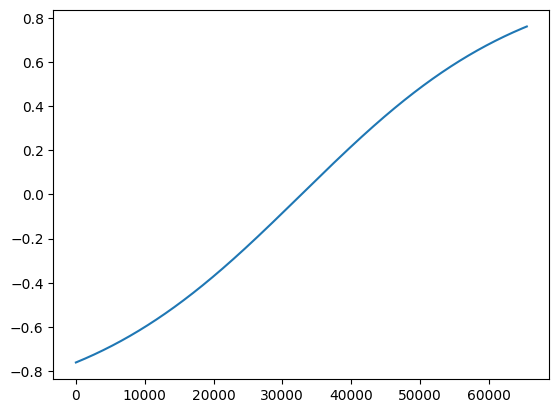

In [53]:
import matplotlib.pyplot as plt
nbits = 16

def f(x):
    return np.tanh(2*x-1)
    return np.sin(2*np.pi*x)

x_l = []
y_l = []
for bit_string in list(product([0, 1], repeat=nbits)):
    x = np.array(bit_string)
    x = x*2 -1
    y = f(int("".join(map(str, bit_string)), 2)/2**nbits)
    x_l.append(x)
    y_l.append(y)
x = np.array(x_l)
y = np.array(y_l)

plt.plot(y)


f_hat = FW_transform(x, y)
print(f'nbits input: {nbits}, degree: {degree(f_hat)}')
print(degree(f_hat)/nbits)

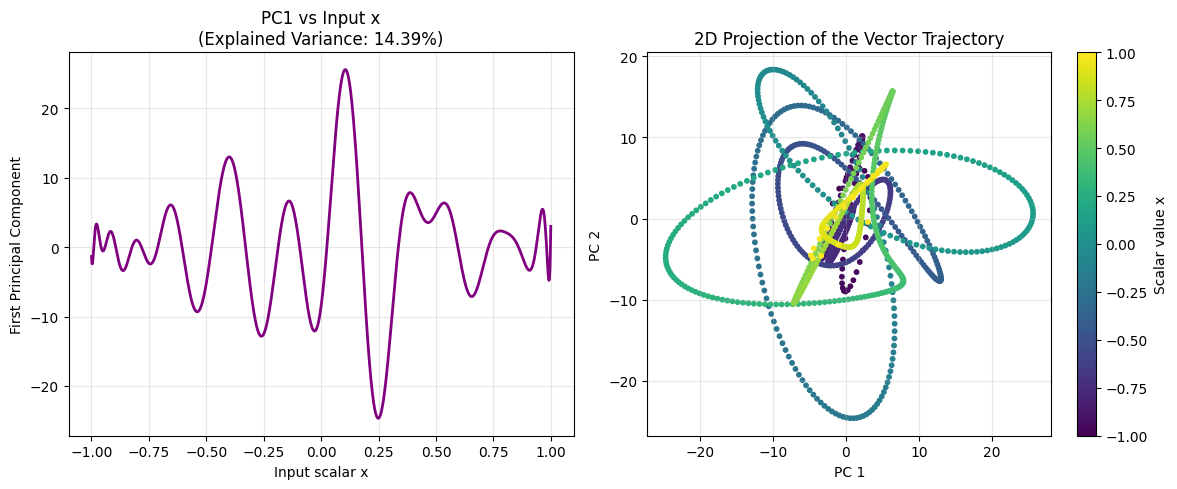

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from numpy.polynomial.chebyshev import chebvander

def generate_twisted_polynomial_vector(x, input_dim=100, min_deg=15, max_deg=30):
    """
    Generates a high-dimensional vector based on x using high-degree polynomials.
    
    Args:
        x (float or np.array): Scalar input in range [-1, 1].
        input_dim (int): The dimension of the output vector.
        min_deg (int): The lowest degree polynomial to use (prevents linearity).
        max_deg (int): The highest degree polynomial to use.
        
    Returns:
        np.array: A high-dimensional vector (or matrix if x is an array).
    """
    # 1. Generate the Vandermonde matrix for Chebyshev polynomials
    # This calculates T_0(x), T_1(x), ... T_max_deg(x)
    # Shape: (n_samples, max_deg + 1)
    polys = chebvander(x, max_deg)
    
    # 2. Slice to keep only high frequencies
    # We discard degrees 0 to min_deg-1 to ensure no monotonic trends exist
    high_freq_polys = polys[:, min_deg:max_deg+1]
    
    # 3. Create a random mixing matrix (fixed seed for reproducibility)
    # We project the polynomial basis into the desired high dimension
    rng = np.random.RandomState(42)
    feature_dim = high_freq_polys.shape[1]
    W = rng.randn(feature_dim, input_dim)
    
    # 4. Mix the polynomials
    high_dim_vector = high_freq_polys @ W
    
    return high_dim_vector

# --- Execution and Visualization ---

# 1. Create the input domain
x_vals = np.linspace(-1, 1, 1000)

# 2. Generate the high-dimensional vectors
# We use min_deg=10 to ensure the "slowest" change is still an oscillation
Y = generate_twisted_polynomial_vector(x_vals, input_dim=50, min_deg=10, max_deg=30)

# 3. Compute PCA to find the direction of maximum variance
pca = PCA(n_components=2)
Y_pca = pca.fit_transform(Y)

# 4. Visualization
plt.figure(figsize=(12, 5))

# Plot PC1 vs Input x
plt.subplot(1, 2, 1)
plt.plot(x_vals, Y_pca[:, 0], color='purple', lw=2)
plt.title(f"PC1 vs Input x\n(Explained Variance: {pca.explained_variance_ratio_[0]:.2%})")
plt.xlabel("Input scalar x")
plt.ylabel("First Principal Component")
plt.grid(True, alpha=0.3)

# Plot PC1 vs PC2 (The Manifold)
plt.subplot(1, 2, 2)
# Using a scatter with color map to show the progression of x
plt.scatter(Y_pca[:, 0], Y_pca[:, 1], c=x_vals, cmap='viridis', s=10)
plt.colorbar(label='Scalar value x')
plt.title("2D Projection of the Vector Trajectory")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from itertools import combinations

# --- 1. Setup Data & Latents (2 Dimensions) ---
# We create a grid of (s, a) values to define the manifold
# s in [-1, 1], a in [-0.1, 0.1]
s_values = np.linspace(-0.5, 0.5, 11)       # 4 values
a_values = np.linspace(-0.1, 0.1, 3)   # 4 values

# Create the cartesian product (grid) of s and a
# This gives us 16 distinct latent states (4x4)
Z_grid = np.array(np.meshgrid(s_values, a_values)).T.reshape(-1, 2)
s = Z_grid[:, 0]
a = Z_grid[:, 1]

N_SAMPLES = len(s) # 16

# Generator phi(z) = [s^2, s^3, a^2, a^3]
# Note: X has 4 continuous dimensions
x_continuous = np.column_stack([s**2, s**4, a**2, a**4])

# Task h(z) = (s + a)^3 + (s + a)^2
y_task = (s + a)**3 + (s + a)**2

print(f"--- Data Stats ---")
print(f"Latent Samples: {N_SAMPLES}")
print(f"Latent s range: [{s.min()}, {s.max()}]")
print(f"Latent a range: [{a.min()}, {a.max()}]")
print(f"X shape: {x_continuous.shape}")


# --- 2. Robust Boolean Encoding ---
# We need to encode 4 continuous features into bits.
# Crucial: We must normalize EACH column independently because 
# a^2 (approx 0.01) is much smaller than s^2 (approx 1.0).

BITS_PER_FEATURE = 5 # Total bits m = 4 features * 5 bits = 20 bits

def quantize_matrix(X, n_bits):
    """Quantizes each column of X to n_bits independently."""
    n_rows, n_cols = X.shape
    X_bool_list = []
    
    for col_idx in range(n_cols):
        col_vals = X[:, col_idx]
        min_v, max_v = col_vals.min(), col_vals.max()
        
        # Avoid division by zero if a feature is constant
        if max_v == min_v:
            max_v += 1e-9
            
        # Normalize to 0..1
        norm = (col_vals - min_v) / (max_v - min_v)
        
        # Scale to integer levels
        levels = 2**n_bits
        ints = np.floor(norm * levels).astype(int)
        ints = np.clip(ints, 0, levels - 1)
        
        # Convert integers to bit vectors [-1, 1]
        col_bits = []
        for val in ints:
            bits = [1 if (val >> b) & 1 else -1 for b in range(n_bits)]
            col_bits.append(bits)
        X_bool_list.append(col_bits)
        
    # Concatenate all feature bits horizontally
    # Shape: (N_SAMPLES, n_cols * n_bits)
    X_bool = np.hstack(X_bool_list)
    return X_bool

X_bool = quantize_matrix(x_continuous, BITS_PER_FEATURE)
m = X_bool.shape[1]

# Check for collisions
unique_rows = np.unique(X_bool, axis=0)
if len(unique_rows) < N_SAMPLES:
    print(f"\n[ERROR] Collision! {len(unique_rows)} unique vs {N_SAMPLES} samples.")
    exit()
else:
    print(f"\n[OK] Encoding clean. Input Dimension m = {m} bits")


# --- 3. Iterative Search for h* ---
# We look for the lowest degree polynomial that solves the task.
# We expect degree 3 because the task is cubic: (s+a)^3...

max_search_degree = 4 # We search up to degree 4
all_indices = range(m)

# Pre-generate basis functions is too slow for m=20 if we do ALL combinations.
# Optimization: We generate basis functions on the fly or limit the search space.
# For this demo, we use the same strict logic but optimized loop.

print("\n--- Solving for h* ---")

final_degree = -1

for d_try in range(max_search_degree + 1):
    print(f"Checking Degree {d_try}...", end="")
    
    # Generate all subsets of size 'd_try'
    # For m=20, d=3 is manageable (1140 combinations), d=4 is 4845.
    basis_subsets = list(combinations(all_indices, d_try))
    
    # Build Design Matrix for THIS degree ONLY (to check if we can add it to previous)
    # Actually, proper forward selection adds degrees cumulatively.
    # Let's rebuild the FULL matrix up to degree d_try.
    
    full_basis_indices = []
    for r in range(d_try + 1):
        full_basis_indices.extend(list(combinations(all_indices, r)))
        
    n_features = len(full_basis_indices)
    print(f" (Features: {n_features}) -> ", end="")
    
    # Construct A matrix
    A = np.zeros((N_SAMPLES, n_features))
    
    for i in range(N_SAMPLES):
        # We need to compute product of bits for each subset
        # Optimization: Use fancy indexing if possible, or simple loop
        # Given small N_SAMPLES, loop is fine.
        row_bits = X_bool[i]
        for col, subset in enumerate(full_basis_indices):
            val = 1
            for idx in subset:
                val *= row_bits[idx]
            A[i, col] = val
            
    # Solve
    model = LinearRegression(fit_intercept=False)
    model.fit(A, y_task)
    preds = model.predict(A)
    mse = np.mean((preds - y_task)**2)
    
    print(f"MSE: {mse:.10f}")
    
    if mse < 1e-9:
        final_degree = d_try
        break

# --- 4. Analysis ---
print("\n--- Results ---")
if final_degree != -1:
    print(f"Found h* at Degree: {final_degree}")
    # Effective Latent Dimension d:
    # We have 16 samples. If they are independent, d = log2(16) = 4.
    # However, s and a are continuous manifolds.
    # The degree bound should hold relative to the complexity of the task on the manifold.
    
    print(f"Task is cubic (degree 3). Found degree {final_degree}.")
    if final_degree <= 3:
        print("Success: Matches theoretical expectation (Degree <= 3).")
    else:
        print("Note: Degree is higher than 3. This is common with discretization noise.")
else:
    print("Failed to find solution in search range.")

--- Data Stats ---
Latent Samples: 33
Latent s range: [-0.5, 0.5]
Latent a range: [-0.1, 0.1]
X shape: (33, 4)

[ERROR] Collision! 12 unique vs 33 samples.

--- Solving for h* ---
Checking Degree 0... (Features: 1) -> MSE: 0.0160995556
Checking Degree 1... (Features: 21) -> MSE: 0.0082773333
Checking Degree 2... (Features: 211) -> MSE: 0.0082773333
Checking Degree 3... (Features: 1351) -> MSE: 0.0082773333
Checking Degree 4... (Features: 6196) -> MSE: 0.0082773333

--- Results ---
Failed to find solution in search range.


: 

In [1]:
s_values

NameError: name 's_values' is not defined

In [19]:
X_bool

array([[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
       [ 1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
       [-1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
       [-1,  1, -1,  1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1, -1, -1],
       [-1,  1, -1, -1,  1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1, -1],
       [-1, -1,  1,  1,  1, -1, -1, -1,  1, -1, -1,  1, -1, -1, -1, -1],
       [-1, -1, -1,  1, -1,  1, -1, -1, -1, -1, -1, -1,  1, -1, -1, -1],
       [ 1,  1,  1, -1,  1,  1, -1, -1, -1,  1, -1,  1,  1, -1, -1, -1],
       [-1, -1, -1,  1, -1, -1,  1, -1, -1,  1,  1, -1, -1,  1, -1, -1],
       [-1, -1,  1,  1,  1, -1,  1, -1,  1,  1,  1, -1,  1,  1, -1, -1],
       [ 1, -1, -1, -1,  1,  1,  1, -1,  1,  1, -1,  1, -1, -1,  1, -1],
       [ 1, -1, -1,  1, -1, -1, -1,  1, -1, -1,  1, -1, -1,  1,  1, -1],
       [ 1,  1, -1, -1, -1,  1, -1,  1,  1,  1, -1, -1, -1, -1, -1,  1],
       [-1, -1, -1, -1, -1, -1,  1,  1, -1,  1,  1,